**Manipulating Excel spreadsheets using openpyxl lib**

In [1]:
!python --version

Python 3.9.12


In [2]:
import openpyxl

In [3]:
work_book = openpyxl.load_workbook('company_revenue.xlsx') ## to load existing workbooks

In [4]:
work_book.sheetnames

## Note that the return value is a list and it contains the sheet name (just 1 element which is a string) . I added Test.

['revenue', 'Test']

In [5]:
work_book['revenue']

<Worksheet "revenue">

In [6]:
sheet_obj = work_book['revenue']

In [63]:
sheet_obj1=work_book['Test']

In [64]:
sheet_obj.title

'revenue'

In [65]:
sheet_obj1.title

'Test'

In [66]:
sheet_obj['A1'] ## What we get is a cell object. The cell object is pretty much analogous to the worksheet cell

<Cell 'revenue'.A1>

In [67]:
sheet_obj['A1'].value

'Company'

In [68]:
cell = sheet_obj['B1']

In [69]:
cell.value

'Country'

In [70]:
type(cell)

openpyxl.cell.cell.Cell

In [71]:
dir(cell) ##This dir is an inbuilt function whihc efectivley returns a list of the attributes and the methods of any 
          ##object that we pass in.
          ## Most of these attribuyes can be used to manipulate a cell object.

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '_bind_value',
 '_comment',
 '_hyperlink',
 '_style',
 '_value',
 'alignment',
 'base_date',
 'border',
 'check_error',
 'check_string',
 'col_idx',
 'column',
 'column_letter',
 'comment',
 'coordinate',
 'data_type',
 'encoding',
 'fill',
 'font',
 'has_style',
 'hyperlink',
 'internal_value',
 'is_date',
 'number_format',
 'offset',
 'parent',
 'pivotButton',
 'protection',
 'quotePrefix',
 'row',
 'style',
 'style_id',
 'value']

In [72]:
cell.row ## we get 1 because we are in row 1 of our spreadsheet..line 16. this is refering to B1

1

In [73]:
cell.column ## we get 2, cos this was a cell reference to B1, column B has the index 2

2

In [74]:
cell.value

'Country'

In [396]:
## IMPORTANT - Even though Python lists and collections are indexed startting from 0, excel indices start from 1.
## So the first row is row number 1 , not row number 0.Same with Columns

In [75]:
cell1= sheet_obj['C1']

In [76]:
type(cell1)

openpyxl.cell.cell.Cell

In [77]:
cell1.row

1

In [78]:
cell1.column

3

In [84]:
cell1.value

'Revenue (billion $)'

In [85]:
cell2= sheet_obj['c10'] ## sheet_obj = work_book['revenue']

In [89]:
cell2.value

287

In [81]:
cell2.row

10

In [82]:
cell2.column

3

In [83]:
cell2.value

287

**Accessing data in openpyxl**

*Some more properties of an individual cell*

In [346]:
cell2.number_format

'General'

In [347]:
cell2.coordinate

'C10'

In [348]:
cell2.data_type ##n corresponds to an integer

'n'

In [409]:
cell1.data_type ## s corresponds to a string

's'

In [410]:
cell.data_type

's'

In [411]:
cell2.value

287

In [412]:
## Lets see what we can do by combining values present in different cell

In [90]:
sheet_obj

<Worksheet "revenue">

In [91]:
sheet_obj['a1']

<Cell 'revenue'.A1>

In [92]:
sheet_obj['a1'].value

'Company'

In [93]:
sheet_obj['a2'].data_type

's'

In [109]:
sheet_obj['a2'].value +\
', based in ' + sheet_obj['b2'].value +\
' has a revenue of $' + str(sheet_obj['c2'].value) +\
'billion.'

'Walmart, based in United States has a revenue of $514billion.'

In [111]:
sheet_obj['B1']

<Cell 'revenue'.B1>

In [112]:
sheet_obj['B1'].value           ## sheet_obj = work_book['revenue']
                                ## work_book = openpyxl.load_workbook('company_revenue.xlsx') 

'Country'

In [113]:
sheet_obj.cell(row=1, column=2)

<Cell 'revenue'.B1>

In [114]:
sheet_obj.cell(row=1, column=2).value

'Country'

In [115]:
## Another interesting propertysheet_obj = work_book['revenue']

sheet_obj.max_row

11

In [117]:
sheet_obj.max_column 

3

In [118]:
sheet_obj['c1'].value

'Revenue (billion $)'

In [119]:
max_col = sheet_obj.max_column
max_row = sheet_obj.max_row

max_col

3

In [120]:
max_row

11

In [133]:
cell_ob=sheet_obj.cell(row=1,column=2)

cell_ob

<Cell 'revenue'.B1>

In [134]:
cell_ob.value

'Country'

In [135]:
c_ob = sheet_obj['a1':'c1']

c_ob

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),)

In [136]:
c_ob.value      ## Observe the diff between line 467 and 709..467 refers to a single cell and hence the .value works.
                ##  line 709 refers to a tuple with multiple cell (range). HEnce  .value doesn't work.
                ## Now try below

AttributeError: 'tuple' object has no attribute 'value'

In [137]:
c_ob1 = sheet_obj['a1']

c_ob1

<Cell 'revenue'.A1>

In [138]:
c_ob1.value       ## This works as it refers to a single cell.

'Company'

In [162]:
for i in range(1, max_col+1):  ## This is because Python is zero based indexing when excel has indexes starting from 1
    
    cell_obj = sheet_obj.cell(row=1,column=i)
    print(cell_obj.value)

Company
Country
Revenue (billion $)


In [163]:
for i in range(1, max_row+1):
    
    cell_obj = sheet_obj.cell(row=i,column=1)
    print(cell_obj.value)

Company
Walmart
Sinopec Group
Royal Dutch Shell
China National Petroleum
State Grid
Saudi Aramco
BP
Exxon Mobil
Volkswagen
Toyota Motors


In [141]:
c= sheet_obj['A1']
c.value

'Company'

In [143]:
## Lets work with ranges

In [144]:
sheet_obj['A1':'C1'] ##Return value is a range which is defined by a pair of tuples.

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),)

In [145]:
sheet_obj['A1':'C3']

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),
 (<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>),
 (<Cell 'revenue'.A3>, <Cell 'revenue'.B3>, <Cell 'revenue'.C3>))

In [146]:
## Lets try to iterate over all of the cells in this range and print some properties

In [156]:
for rows in sheet_obj['A1':'C3']:
    ## as this is a rectangular region, we need a nested FOR loop. Outer loop is a row and inner loop corresponds to the 
    for cell in rows:                     ## individual cell.For ranges, we always need nested for loops to iterate.
        
        print(cell.coordinate, cell.value, cell.data_type)
        
    print('-----------------------')

A1 Company s
B1 Country s
C1 Revenue (billion $) s
-----------------------
A2 Walmart s
B2 United States s
C2 514 n
-----------------------
A3 Sinopec Group s
B3 China s
C3 415 n
-----------------------


In [164]:
sheet_obj['A1':'C3']


((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),
 (<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>),
 (<Cell 'revenue'.A3>, <Cell 'revenue'.B3>, <Cell 'revenue'.C3>))

In [158]:
for rows in sheet_obj['A1':'C3']:
    ## as this is a rectangular region, we need a nested FOR loop. Outer loop is a row and inner loop corresponds to the 
    print(rows)

(<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>)
(<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>)
(<Cell 'revenue'.A3>, <Cell 'revenue'.B3>, <Cell 'revenue'.C3>)


In [159]:
for rows in sheet_obj['A1':'C3']:
    ## as this is a rectangular region, we need a nested FOR loop. Outer loop is a row and inner loop corresponds to the 
    for cell in rows:                     ## individual cell.For ranges, we always need nested for loops to iterate.
        
        print(cell)
   

<Cell 'revenue'.A1>
<Cell 'revenue'.B1>
<Cell 'revenue'.C1>
<Cell 'revenue'.A2>
<Cell 'revenue'.B2>
<Cell 'revenue'.C2>
<Cell 'revenue'.A3>
<Cell 'revenue'.B3>
<Cell 'revenue'.C3>


In [349]:
sheet_obj['a1':'c1']

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),)

In [160]:
for rows in sheet_obj['A1':'C1']: 
    
    print(rows.coordinate, rows.value)
        
print('-----------------------')

AttributeError: 'tuple' object has no attribute 'coordinate'

In [350]:
sheet_obj['A1':'C1']

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),)

**Manipulating Rows and columns**

In [177]:
## Lets get rid of the inner for loop and only itearte over a range and print out info for each row.
## We will use iter_rows method of the sheet object.

In [178]:
for row in sheet_obj.iter_rows(min_row=1,
                               max_row=2,
                               min_col=1,
                               max_col=3):
    print(row)


(<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>)
(<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>)


In [183]:
## The above is same as 

sheet_obj['A1':'C2']

((<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>),
 (<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>))

In [184]:
## This is because there is another iteration happening under the hood inside the iter_rows method of the sheet obj.

In [185]:
for value in sheet_obj.iter_rows(min_row=1,
                               max_row=2,
                               min_col=1,
                               max_col=3,
                               values_only=True):  ##New input arg called values_only. if this is equal to be True, 
                                                   ##we get only the values wihout the metadata.
    print(value)


('Company', 'Country', 'Revenue (billion $)')
('Walmart', 'United States', 514)


In [215]:
for value in sheet_obj.iter_rows(min_row=1,
                               max_row=2,
                               min_col=1,
                               max_col=3,
                               values_only=False):  
                                                   
    print(value)



(<Cell 'revenue'.A1>, <Cell 'revenue'.B1>, <Cell 'revenue'.C1>)
(<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>)


In [222]:
##Similarly we have iter_Cols method

for cols in sheet_obj.iter_cols(min_row=1,
                               max_row=2,
                               min_col=1,
                               max_col=3,
                               values_only=True):  
                                                   
    print(cols)


('Company', 'Walmart')
('Country', 'United States')
('Revenue (billion $)', 514)


In [223]:
for cols in sheet_obj.iter_cols(min_row=1,
                               max_row=2,
                               min_col=1,
                               max_col=3,
                               values_only=False):  
                                                   
    print(cols)

(<Cell 'revenue'.A1>, <Cell 'revenue'.A2>)
(<Cell 'revenue'.B1>, <Cell 'revenue'.B2>)
(<Cell 'revenue'.C1>, <Cell 'revenue'.C2>)


In [224]:
## Lets see how easy it is to convert from excel to JSON.

In [225]:
import json

In [226]:
revenues ={}

In [209]:
for value in sheet_obj.iter_rows(min_row=2,
                               max_row=4,
                               min_col=1,
                               max_col=3,
                               values_only=False):  
    
    print(value)

(<Cell 'revenue'.A2>, <Cell 'revenue'.B2>, <Cell 'revenue'.C2>)
(<Cell 'revenue'.A3>, <Cell 'revenue'.B3>, <Cell 'revenue'.C3>)
(<Cell 'revenue'.A4>, <Cell 'revenue'.B4>, <Cell 'revenue'.C4>)


In [234]:
for value in sheet_obj.iter_rows(min_row=2,
                               max_row=4,
                               min_col=1,
                               max_col=3,
                               values_only=True):  
    
    print(value)

('Walmart', 'United States', 514)
('Sinopec Group', 'China', 415)
('Royal Dutch Shell', 'Netherlands', 397)


In [229]:
for value in sheet_obj.iter_cols(min_row=2,
                               max_row=4,
                               min_col=1,
                               max_col=3,
                               values_only=False):  
    print(value)

(<Cell 'revenue'.A2>, <Cell 'revenue'.A3>, <Cell 'revenue'.A4>)
(<Cell 'revenue'.B2>, <Cell 'revenue'.B3>, <Cell 'revenue'.B4>)
(<Cell 'revenue'.C2>, <Cell 'revenue'.C3>, <Cell 'revenue'.C4>)


In [213]:
for value in sheet_obj.iter_cols(min_row=2,
                               max_row=4,
                               min_col=1,
                               max_col=3,
                               values_only=True):  
    print(value)

('Walmart', 'Sinopec Group', 'Royal Dutch Shell')
('United States', 'China', 'Netherlands')
(514, 415, 397)


In [235]:
for  row in sheet_obj.iter_rows(min_row=2,
                               max_row=4,
                               min_col=1,
                               max_col=3,
                               values_only=True):  
    
    rep = row[0]     ## Corresponds to Company name
    rev_details = {
        "Country" : row[1],    ## Country
        "Revenu"  : row[2],    ## Revenue
    }
    
    revenues[rep] = rev_details  ## Once we have all the info, we go ahead and pop it into revenue dict
    
##Notice that because we are indexing directly into python collection, this indexing starts from 0 , not 1.

## The key is nothing but the Company Name, the value is a dict whihc contains country and revenue.
## So this is the exactly the kind of nested dict that you would expect to have in json.

In [244]:
## Lets use the json dumps method and convert this dict, rather this nested dictionary into proper JSON.

print(json.dumps(revenues, indent=4, sort_keys=True))

{
    "Royal Dutch Shell": {
        "Country": "Netherlands",
        "Revenu": 397
    },
    "Sinopec Group": {
        "Country": "China",
        "Revenu": 415
    },
    "Walmart": {
        "Country": "United States",
        "Revenu": 514
    }
}


In [245]:
print(json.dumps(revenues, indent=4, sort_keys=False))

{
    "Walmart": {
        "Country": "United States",
        "Revenu": 514
    },
    "Sinopec Group": {
        "Country": "China",
        "Revenu": 415
    },
    "Royal Dutch Shell": {
        "Country": "Netherlands",
        "Revenu": 397
    }
}


**Writing to Spreadsheets**

In [249]:
##Lets see how to write to excel using openpyxl

In [1]:
import openpyxl

In [2]:
## Open a brand new completely empty workbook. This is something we are doing in memory.We are basically creating a 
## workbook obj, which we will proceed to manipulate.

work_book=openpyxl.Workbook()

In [3]:
work_book.active   ##This work book has an active sheet. We will use active property to see what sheet it is

<Worksheet "Sheet">

In [4]:
work_book.sheetnames

['Sheet']

In [5]:
## We see that this worksheet has the name Sheet. It means this empty workbook has just one sheet and its called Sheet

In [6]:
## Lets go ahead and get a handle to this sheet

sheet = work_book['Sheet']

In [7]:
sheet

<Worksheet "Sheet">

In [8]:
##Lets write values now. Keep in mind this is all being done in-memory.We are yet to flush these changes out to disk

sheet['A1'] = 'Hello'
sheet['B1'] = 'Excel'
sheet['C1'] = 'Users!'

In [9]:
sheet['A1'].value

'Hello'

In [10]:
sheet['B1'].value

'Excel'

In [11]:
work_book['Sheet']['C1'].value

'Users!'

In [12]:
##Now lets write this to disk...See below. Its saved to the disk

work_book.save('brand_new_workbook.xlsx')

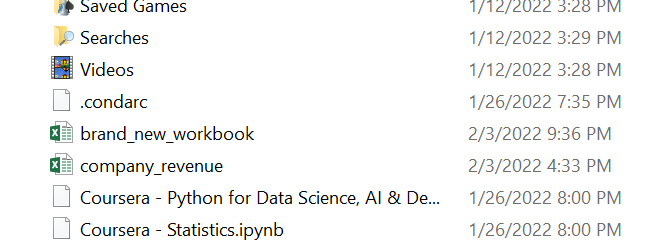

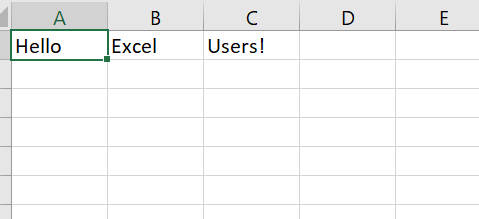

In [13]:
##Lets change values

sheet['A1'] = 'Goodbye'
sheet['B1'] = 'Excel Users'
sheet['C1'] = '!'

In [14]:
sheet['A1'].value

'Goodbye'

In [15]:
work_book.save('brand_new_workbook.xlsx') ## We need to invoke the save method everytime

In [16]:
##Now its written to disk

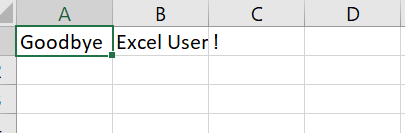

In [266]:
## Lets see some other methods

sheet.calculate_dimension()

'A1:C1'

In [267]:
##Now lets append

sheet.append(['one','two','three', 'four']) ## This will append a new row of text

In [268]:
sheet['a2'].value

'one'

In [269]:
##Lets write it to desk

work_book.save('brand_new_workbook.xlsx')

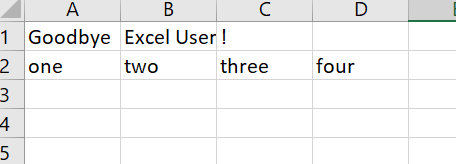

In [270]:
##See that two rows are written

In [271]:
sheet.calculate_dimension()

'A1:D2'

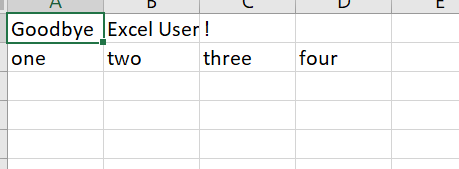

**Manipulating Data in Files**

In [273]:
## Lets insert rows

sheet.insert_rows(idx=2, amount =3) ## We are inserting 3 rows starting from row 2.

In [274]:
sheet.insert_cols(idx=3,amount=2) ## A single cols will be added at index 3 i.e column C. Columns in excel are indexed starting from 1
## Corresponding to Col A, so if idx =3, then new col will be inserted at position C

In [275]:
sheet.calculate_dimension() ## AS we inserted rows and cols multiple times, the dimension will reflect the change

'A1:F8'

In [278]:
##Lets save it again

work_book.save('brand_new_workbook.xlsx')    ## This is important!!!

## AS you can see below, 3 rows have been added from row 2 amd 3rd col is added

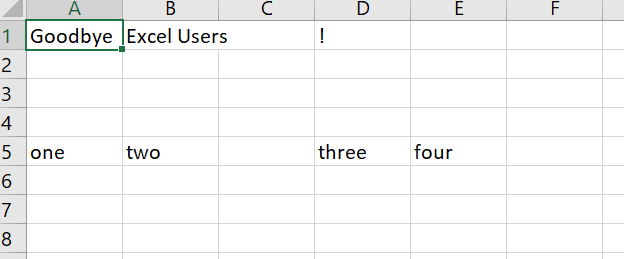

In [279]:
## Lets see if we can delete rows

sheet.delete_rows(idx=2, amount=3)

In [280]:

sheet.delete_cols(idx=3)

In [281]:
sheet.calculate_dimension()

'A1:E5'

In [282]:
work_book.save('brand_new_workbook.xlsx')  

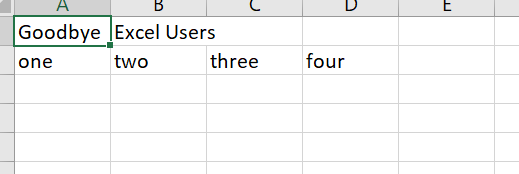

In [283]:
## Lets change the sheet name

sheet.title = 'FirstSheet'
work_book.save('brand_new_workbook.xlsx')  

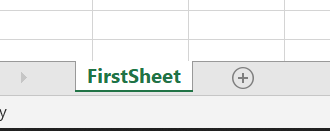

In [284]:
## Its also possible to write data into sheets using a list of lists.Here is a list of list

data =[['Planet', 'Radius (km)', 'Distance from Sun (M Km)'],
      ['Earth', 6371, 150], ['Mars', 3389, 228], ['Mercury', 2440, 58]]

In [285]:
## Lets write this data to a brand new workbook

planet_wb =openpyxl.Workbook()

In [286]:
planet_wb.active

<Worksheet "Sheet">

In [287]:
## To access the sheet

planet_sheet = planet_wb['Sheet']

In [288]:
planet_sheet.title = 'Planets'

In [289]:
planet_sheet.title

'Planets'

In [290]:
for row in data:
    planet_sheet.append(row)

In [291]:
planet_sheet.calculate_dimension()

'A1:C4'

In [292]:
planet_wb.save('Planets.xlsx')

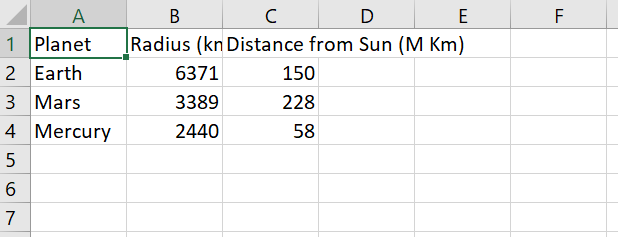

**Exercise for myself**

In [293]:
import openpyxl
test_bk=openpyxl.load_workbook('zomato_reviews.xlsx')

In [294]:
test_bk.sheetnames

['zomato']

In [543]:
sheet_test=test_bk['zomato']

In [544]:
sheet_test['a1'].value

'Restaurant ID'

In [545]:
cell=sheet_test['a1']

cell

<Cell 'zomato'.A1>

In [546]:
type(cell)

openpyxl.cell.cell.Cell

In [547]:
cell.value

'Restaurant ID'

In [548]:
sheet_test.cell(row=1,column=2).value

'Restaurant Name'

In [549]:
sheet_test['A1':'D1']

((<Cell 'zomato'.A1>,
  <Cell 'zomato'.B1>,
  <Cell 'zomato'.C1>,
  <Cell 'zomato'.D1>),)

In [550]:
for rows in sheet_test['A1':'I2']:
    ## as this is a rectangular region, we need a nested FOR loop. Outer loop is a row and inner loop corresponds to the 
    for cell in rows:                     ## individual cell.
        
        print(cell.coordinate, cell.value)
        
    print('-----------------------')

A1 Restaurant ID
B1 Restaurant Name
C1 Country Code
D1 City
E1 Address
F1 Cuisines
G1 Price range
H1 Aggregate rating
I1 Rating text
-----------------------
A2 6317637
B2 Le Petit Souffle
C2 162
D2 Makati City
E2 Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City
F2 French, Japanese, Desserts
G2 3
H2 4.8
I2 Excellent
-----------------------


**Freezing Panes**

In [295]:
import openpyxl
work_book=openpyxl.load_workbook('zomato_reviews.xlsx')

In [296]:
work_book.sheetnames

['zomato']

In [297]:
s=work_book['zomato']

In [298]:
s.title

'zomato'

In [299]:
s['a2'].value

6317637

In [300]:
s['a1':'c2']

((<Cell 'zomato'.A1>, <Cell 'zomato'.B1>, <Cell 'zomato'.C1>),
 (<Cell 'zomato'.A2>, <Cell 'zomato'.B2>, <Cell 'zomato'.C2>))

In [301]:
s.unfreeze_panes = 'D2'

In [302]:
work_book.save('zomato_reviews.xlsx')

In [303]:
sheet = work_book.active ## we use the active property in order to get a handle to the active worksheet

In [306]:
## Lets try freeze option now

sheet.freeze_panes ='A2' ##This is applying freeze pane operation with the cursor at position A2. This means all rows above 
                         ## the current row (2) and all columns left of the current col (A) will be frozen.
                         ## In this case, there are no cols to the left, however there is a row 1 above row 2
                         ## which will be frozen.  SO this is equivalent to freezing the top row.

In [307]:
work_book.save('zomato_reviews.xlsx')

In [308]:
 ## No check the xls..First row frozen

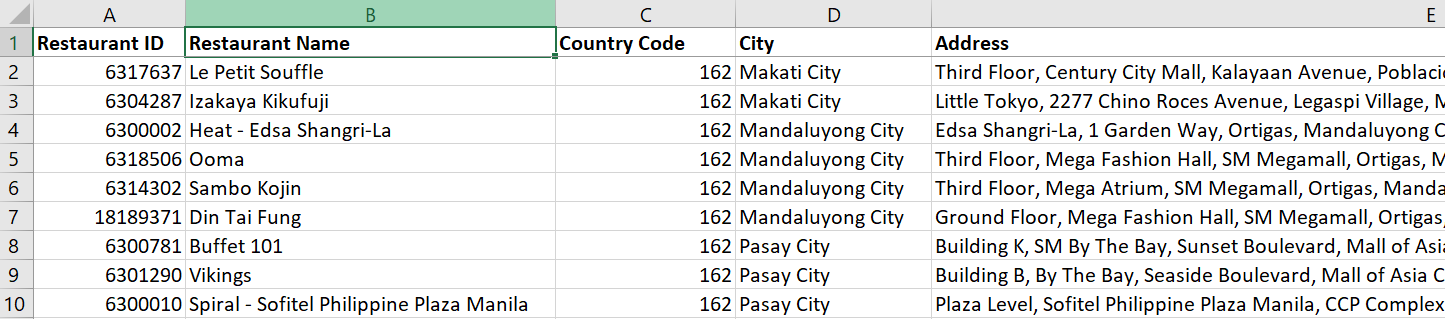

In [309]:
sheet.freeze_panes='B1' # Column A will be frozen now

In [310]:
work_book.save('zomato_reviews.xlsx') ## Verified.

In [311]:
sheet.freeze_panes = 'C2' ## Column A and B will be frozen. Row 1 will be frozen 

In [313]:
work_book.save('zomato_reviews.xlsx') ## Verified

**Filtering and Sorting Data**

In [314]:
## Lets create a new workbook

import openpyxl

In [316]:
work_book = openpyxl.Workbook()  ##This is purely in memory at this point in time as we have not written it out to disk.

In [317]:
work_sheet = work_book.active

In [318]:
work_book.sheetnames

['Sheet']

In [319]:
work_sheet

<Worksheet "Sheet">

In [320]:
work_sheet['a1']

<Cell 'Sheet'.A1>

In [719]:
## Now lets set up the data: We hav ethe complex data sturcu data whihc is a list of lists. Data not sorted.

In [321]:
data = [["Champion", "Year"],
        ["France", 2018],
        ["Spain", 2010],
        ["Italy", 2006],
        ["France", 1998],
        ["Brazil", 1994],
        ["Argentina", 1986],
        ["Italy", 1982],
        ["Argentina", 1978],
        ["Germany", 1974],
        ["Brazil", 1970],
        ["England", 1966],
        ["Brazil", 1962],
        ["Brazil", 1958],
        ["Germany", 2014],
        ["Germany", 1954],
        ["Uruguay", 1950],
        ["Italy", 1938],
        ["Italy", 1934],
        ["Uruguay", 1930],
        ["Germany", 1990],
        ["Brazil", 2002]]

In [322]:
for r in data:
    work_sheet.append(r)

In [323]:
work_sheet['a3'].value

'France'

In [324]:
work_book.save('world_cup_winners_new.xlsx')

In [330]:
work_sheet.calculate_dimension() ## to know the full extent of data

'A1:B23'

In [331]:
## Lets now apply a filter

In [334]:
work_sheet.auto_filter.ref = work_sheet.calculate_dimension()

## This is the Python equivalent of FILTER option in Excel. We nee dto auto_filter property on our worksheet and also specify
## a reference and ref gives the range of cells which we want to filter

In [337]:
work_book.save('world_cup_winners_new.xlsx')

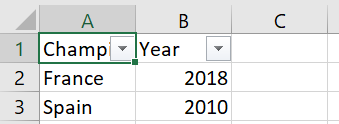

In [338]:
## Next step is to recreate the filtering on the list of values

In [339]:
work_sheet.auto_filter.add_filter_column(0,['Brazil', 'Italy', 'Argentina'])

## The first input arg is the column numbver which is 0 (COl A) and the sec input arg is the list of values.

In [340]:
work_book.save('world_cup_winners_new.xlsx')

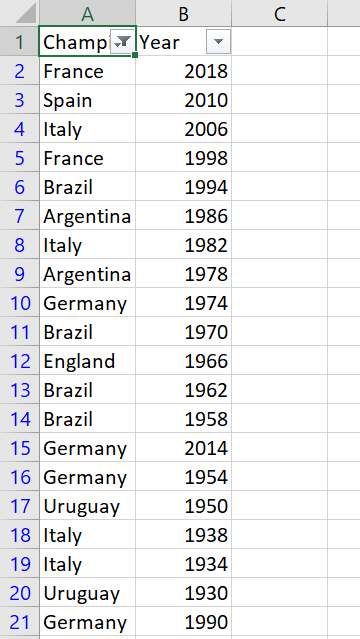

In [341]:
## As you see above, it is not filtered as we expected. We needed only italy, Brazil and Argentina.
## There is a little bug in the openpyxl filtering API.
## We need to reapply the filter manually opening the workbook.
## its definitely a glitch in the way in whihc the filter API in openpyxl works. 
## Lets do additional ops.

In [342]:
## Lets get the full extent of the data by using the negative indexing operator.

In [343]:
work_sheet['B'][1], work_sheet['B'][-1]

## as we expect the return value is a tuple.
## In this way we can see that even though excel is indexed starting at 1, we can still make use of zero-based indexing 
## when we are working within Python

(<Cell 'Sheet'.B2>, <Cell 'Sheet'.B23>)

In [344]:
## Lets construct a range string by merging together the co-ordinates of the cells in these 2 tuples.

In [345]:
range_str = work_sheet['B'][1].coordinate + ':' + work_sheet['B'][-1].coordinate

range_str ## This gives us a nice range string representing all of the data present in column B.

'B2:B23'

In [621]:
##Now lets add this to the sort condition to our filter

In [622]:
work_sheet.auto_filter.add_sort_condition(range_str, descending = True)

## First arg is the range str, which is the str representation of the data we wish to sort.

In [623]:
work_book.save('world_cup_winners.xlsx')

In [625]:
## Again we see that the data is not exactly the way we would need. We can manually remediate this by clicking on the data 
## tab in excel and click reapply.After reapplying :

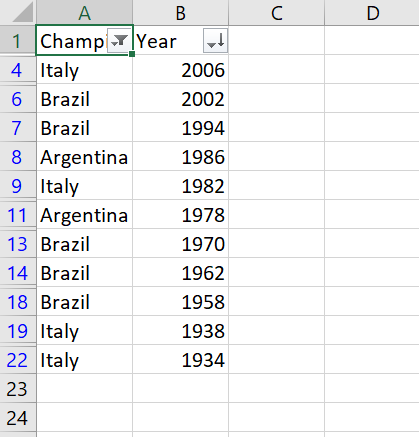

In [626]:
## Thus we saw that even though there is a little bit of a glitch on the API's in openpyxl for filtering and sorting,
## they still allow us to accomplish some pretty cool stuff.

**Resizing Rows and Columns**

In [637]:
work_book =openpyxl.Workbook()

In [638]:
sheet_obj=work_book.active

In [639]:
sheet_obj

<Worksheet "Sheet">

In [640]:
sheet_obj.title

'Sheet'

In [641]:
sheet_obj.title='FirstSheet'

In [642]:
sheet_obj.title

'FirstSheet'

In [643]:
 sheet_obj

<Worksheet "FirstSheet">

In [644]:
sheet_obj['C1'] = 'A high row'
sheet_obj['D4'] = 'A wide column'

In [650]:
## Lets make use of the height property on the first row and set that height prop to 70.This way we can make sure that 
## the first row is going to have a height of 70 pixels.
## same thing for cols. using the WIDTH property.

In [651]:
sheet_obj.row_dimensions[1].height =70
sheet_obj.column_dimensions['D'].width =60

In [653]:
work_book.save('excel_resizing.xlsx')

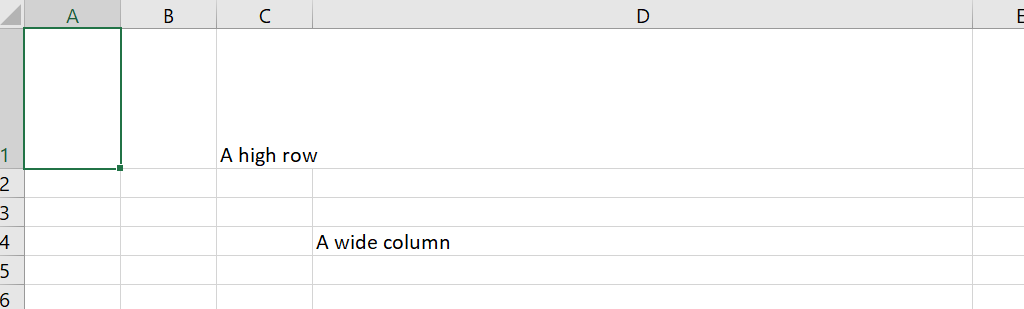

In [654]:
## This is how we rename the worksheet name and resize rows and cols.

In [655]:
## Lets look at Merge cells

In [656]:
## Lets start by inserting a new sheet into our workbook using create sheet function



In [657]:
work_book.create_sheet(title ='Brandnewsheet',index = 0) ## index tells us where we want this new sheet to appear.Notice
## that we specify a zero-based index  This will cause the brandnew sheet to appear first 

<Worksheet "Brandnewsheet">

In [658]:
new_sheet = work_book.active

In [659]:
new_sheet

<Worksheet "Brandnewsheet">

In [661]:
work_book.sheetnames

['Brandnewsheet', 'FirstSheet']

In [662]:
new_sheet

<Worksheet "Brandnewsheet">

In [663]:
work_book.save('dimensions.xlsx')

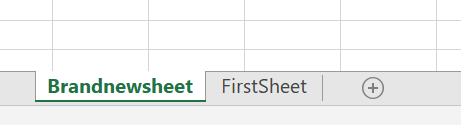

**Merging Rows and cols**

In [664]:
new_sheet

<Worksheet "Brandnewsheet">

In [665]:
new_sheet.merge_cells('A1:D3')

In [667]:
work_book.save('dimensions.xlsx')

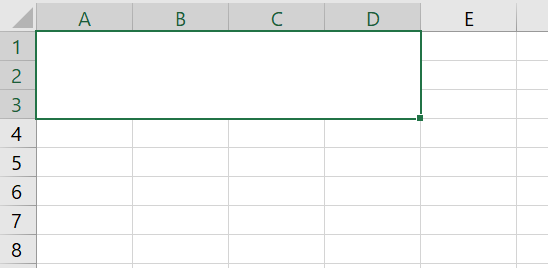

In [670]:
## Lets try to change the value of the cell whihc is in the middle of the merged cell.

new_sheet['C2'] ='Data in a merged cell' ## C2 is in the middle of the cells A1:D3 that were merged.
                                         ## This results in an error.
    ## Error means that we cannot change the values of an individual cell within a merged cell unless we use the cell address 
    ## of the top left corner in this case A1

AttributeError: 'MergedCell' object attribute 'value' is read-only

In [671]:
new_sheet['A1'] ='Data in a merged cell' 

In [672]:
work_book.save('dimensions.xlsx')

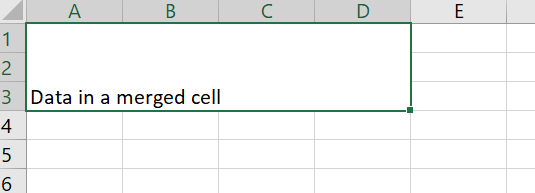

In [674]:
## Lets look at how allignment can be controlled from openpyxl.Start by importing allignment module

In [676]:
from openpyxl.styles import Alignment      ##openpyxl.styles is a namespace

In [678]:
 new_sheet['A1'].alignment = Alignment(horizontal='center')

In [680]:
work_book.save('dimensions.xlsx')

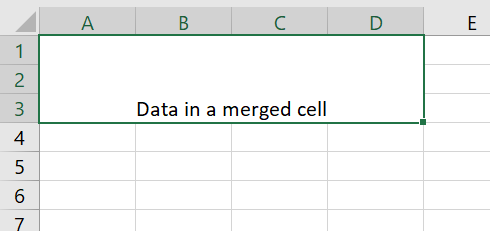

In [681]:
## Lets do vertical alignment

In [684]:
 new_sheet['A1'].alignment = Alignment(vertical='center') ## When we do this, the horizontal alignment we did before will
    ## NOT LAST.

In [686]:
work_book.save('dimensions.xlsx')

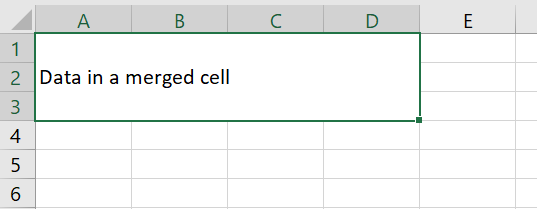

In [688]:
## As see above, horizontal alignment has been lost.These examples show that the alignment styles are not cumulative.
## So if we wnat both h and v, we gotta do so in the same command.

In [689]:
 new_sheet['A1'].alignment = Alignment(horizontal = 'right',vertical='top')

In [691]:
work_book.save('dimensions.xlsx')

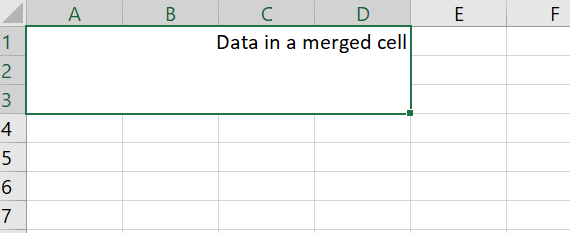

In [692]:
##Lets merge B5:G5

In [693]:
new_sheet.merge_cells('B5:G5') ## equivalent of merge across operation


In [695]:
new_sheet['B5'] ='We just merged the cells in the same row'

In [697]:
new_sheet['B5'].alignment = Alignment(horizontal='center')

In [698]:
work_book.save('dimensions.xlsx')

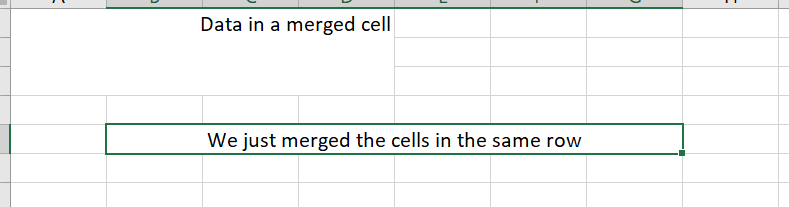

In [699]:
## Course Summary.

## MS EXCEL has an object model that can be leveraged to create and modify workbooks programmatically.
##The oldest such technology was VBA which integrates tighthly with excel.
##

**TEST**